# Notebook: Redes Neuronales Convolucionales (CNN) para Reconocimiento de Caracteres

Este notebook es una guía práctica para aplicar **CNN (Convolutional Neural Networks)** a un problema de clasificación de imágenes relacionado con informática.

Trabajaremos con **EMNIST ByClass**, un conjunto de imágenes de caracteres escritos a mano. Para esta actividad, agruparemos sus etiquetas originales en dos categorías:

- **Letra**
- **Número**

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un experimento con **Data Augmentation**.
- Un ejemplo de **Transfer Learning** usando ResNet18 preentrenada.
- Evaluación con Accuracy, ROC-AUC, Precision, Recall, F1 y matriz de confusión.
- Una visualización de **Grad-CAM** para observar qué zonas del carácter influyen en la predicción.

**Objetivo de la actividad:** construir un sistema capaz de determinar si una imagen de un carácter corresponde a una **letra o un número**.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** y **Torchvision** para construir, entrenar y evaluar los modelos.

El dataset utilizado será **EMNIST ByClass**, por lo que ya no necesitaremos `medmnist`.


In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar y adaptar el dataset EMNIST

**EMNIST ByClass** contiene imágenes de caracteres escritos a mano pertenecientes a diferentes clases de letras y números.

Para esta actividad no nos interesa identificar el carácter exacto. Queremos resolver una clasificación binaria:

- **0 → Letra**
- **1 → Número**

En EMNIST ByClass, las primeras 10 etiquetas corresponden a los dígitos `0-9`, mientras que las etiquetas restantes corresponden a letras.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

from torchvision.datasets import EMNIST

data_root = "./data"

class EMNISTBinary(Dataset):
    def __init__(self, train=True, transform=None, download=True):
        self.dataset = EMNIST(
            root=data_root,
            split="byclass",
            train=train,
            transform=transform,
            download=download
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]

        # EMNIST ByClass:
        # 0-9  -> números
        # 10-61 -> letras
        binary_label = 1 if int(label) < 10 else 0

        return image, binary_label

class_names = ["Letra", "Número"]
num_classes = 2

print("Clases:", class_names)


Clases: ['Letra', 'Número']


In [ ]:
# ============================================================
# SELECCIÓN DE UNA MUESTRA REDUCIDA DE EMNIST
# ============================================================
# Para agilizar el entrenamiento, trabajaremos únicamente
# con 15,000 imágenes, distribuidas en:
# 12,000 para entrenamiento, 1,500 para validación
# y 1,500 para prueba.
#
# La selección mantiene un balance entre letras y números.

transform_basic = T.Compose([
    T.ToTensor()
])

SEED = 42

N_TRAIN = 12_000
N_VAL = 1_500
N_TEST = 1_500

# Cargar EMNIST
full_train_dataset = EMNISTBinary(
    train=True,
    transform=transform_basic,
    download=True
)

full_test_dataset = EMNISTBinary(
    train=False,
    transform=transform_basic,
    download=True
)

# Función para seleccionar cantidades iguales de:
# números (0-9) y letras (10-61)

def balanced_indices(targets, n_samples, seed=42):
    rng = np.random.default_rng(seed)

    targets = np.array(targets)

    number_indices = np.where(targets < 10)[0]
    letter_indices = np.where(targets >= 10)[0]

    n_each = n_samples // 2

    selected_numbers = rng.choice(
        number_indices,
        size=n_each,
        replace=False
    )

    selected_letters = rng.choice(
        letter_indices,
        size=n_each,
        replace=False
    )

    selected = np.concatenate([
        selected_numbers,
        selected_letters
    ])

    rng.shuffle(selected)

    return selected.tolist()


# Obtener etiquetas originales de EMNIST

train_targets = np.array(full_train_dataset.dataset.targets)
test_targets = np.array(full_test_dataset.dataset.targets)


# Seleccionar 13,500 imágenes del conjunto de entrenamiento
# 12,000 train + 1,500 validation
train_val_indices = balanced_indices(
    train_targets,
    N_TRAIN + N_VAL,
    seed=SEED
)

# Mezclar nuevamente antes de separar
rng = np.random.default_rng(SEED)
rng.shuffle(train_val_indices)

train_indices = train_val_indices[:N_TRAIN]
val_indices = train_val_indices[N_TRAIN:N_TRAIN + N_VAL]



# Seleccionar 1,500 imágenes del conjunto de TEST

test_indices = balanced_indices(
    test_targets,
    N_TEST,
    seed=SEED
)


# Crear los subconjuntos

train_dataset = Subset(
    full_train_dataset,
    train_indices
)

val_dataset = Subset(
    full_train_dataset,
    val_indices
)

test_dataset = Subset(
    full_test_dataset,
    test_indices
)


# Verificación

print("========================================")
print("Tamaño de los conjuntos")
print("========================================")
print(f"Entrenamiento : {len(train_dataset):,}")
print(f"Validación    : {len(val_dataset):,}")
print(f"Prueba        : {len(test_dataset):,}")
print("----------------------------------------")
print(f"TOTAL         : {len(train_dataset) + len(val_dataset) + len(test_dataset):,}")
print("========================================")

100%|██████████| 562M/562M [00:08<00:00, 69.1MB/s]


Tamaño de los conjuntos
Entrenamiento : 12,000
Validación    : 1,500
Prueba        : 1,500
----------------------------------------
TOTAL         : 15,000


/tmp/ipykernel_6168/130581419.py:65: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_targets = np.array(full_train_dataset.dataset.targets)
/tmp/ipykernel_6168/130581419.py:66: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_targets = np.array(full_test_dataset.dataset.targets)


### 3.1. Visualizar ejemplos

Antes de entrenar un modelo, observaremos algunas imágenes para comprobar que el dataset y las etiquetas fueron adaptados correctamente.


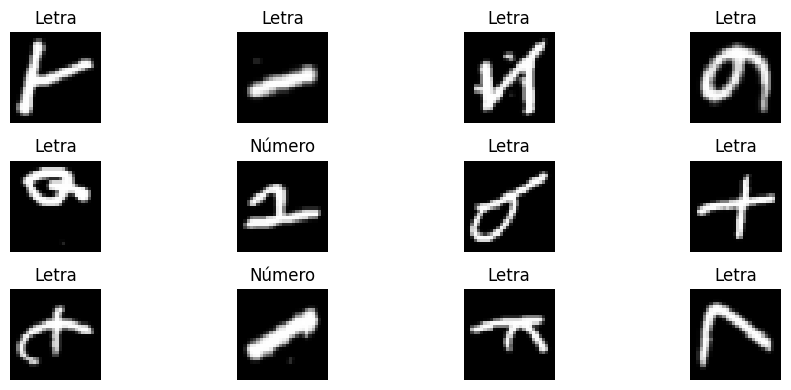

In [ ]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(x.squeeze(0), cmap="gray")
        plt.title(class_names[int(y)])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan los lotes de imágenes durante el entrenamiento.

El **device** permite utilizar GPU cuando está disponible.


In [ ]:
# Utilizamos GPU si está disponible para acelerar el entrenamiento.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
# Los DataLoaders dividen las imágenes en lotes (batches)
# para facilitar y acelerar el entrenamiento de los modelos.

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN sencilla para aprender directamente los patrones visuales de las imágenes de EMNIST.

La red utiliza:
- Capas convolucionales.
- ReLU.
- Max Pooling.
- Un clasificador final con **2 salidas**: letra y número.


In [ ]:
# CNN DESDE CERO
# Se construye una CNN sencilla para establecer un modelo
# base y posteriormente comparar su rendimiento con
# Data Augmentation y Transfer Learning.

import torch.nn.functional as F

num_classes = 2

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

Como se trata de una clasificación binaria, utilizaremos:

- **Accuracy:** porcentaje de predicciones correctas.
- **ROC-AUC:** capacidad del modelo para separar las dos clases.
- **Matriz de confusión:** permite observar letras y números clasificados correctamente o confundidos.
- **Precision, Recall y F1:** permiten analizar el comportamiento de cada clase.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos la CNN durante algunas épocas y registraremos la pérdida y las métricas de validación.


In [ ]:
# ENTRENAMIENTO DE LA CNN
# Entrenamos el modelo durante varias épocas y evaluamos
# su rendimiento sobre el conjunto de validación después
# de cada época.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.6863 | val_acc=0.6247 | val_auc=0.7413
Epoch 02 | train_loss=0.5991 | val_acc=0.7233 | val_auc=0.7990
Epoch 03 | train_loss=0.5397 | val_acc=0.7353 | val_auc=0.8235
Epoch 04 | train_loss=0.5125 | val_acc=0.7547 | val_auc=0.8357
Epoch 05 | train_loss=0.4978 | val_acc=0.7660 | val_auc=0.8473
Epoch 06 | train_loss=0.4880 | val_acc=0.7487 | val_auc=0.8544
Epoch 07 | train_loss=0.4775 | val_acc=0.7720 | val_auc=0.8607
Epoch 08 | train_loss=0.4878 | val_acc=0.7747 | val_auc=0.8658


### 5.3. Curvas de entrenamiento

Visualizamos la evolución de la pérdida y de las métricas para observar el comportamiento del modelo durante el entrenamiento.


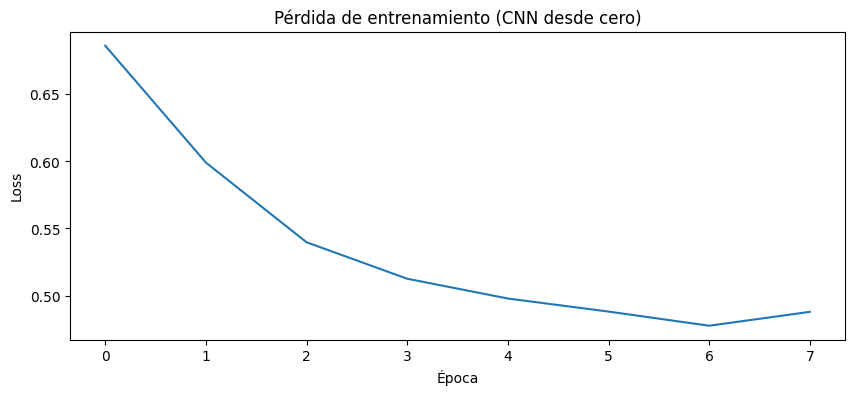

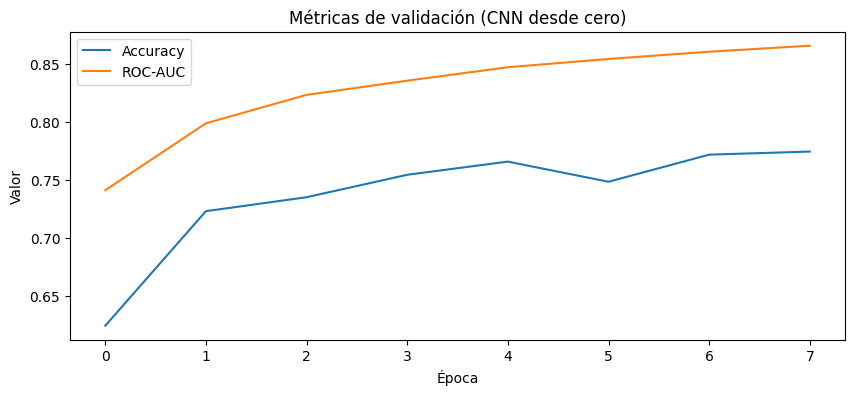

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

Evaluaremos el modelo con imágenes que no fueron utilizadas durante el entrenamiento.


In [ ]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model_scratch,
    test_loader
)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print()
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.7640
Test ROC-AUC: 0.8669

              precision    recall  f1-score   support

       Letra     0.8333    0.6600    0.7366       750
      Número     0.7185    0.8680    0.7862       750

    accuracy                         0.7640      1500
   macro avg     0.7759    0.7640    0.7614      1500
weighted avg     0.7759    0.7640    0.7614      1500



array([[495, 255],
       [ 99, 651]])

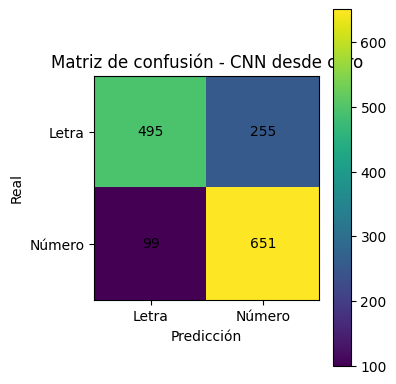

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión - CNN desde cero")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()


## 6. Data Augmentation (aumento de datos)

El **Data Augmentation** genera variaciones de las imágenes de entrenamiento para ayudar al modelo a generalizar.

Para caracteres escritos a mano utilizaremos transformaciones moderadas, como:
- Pequeñas rotaciones.
- Pequeñas traslaciones.

El objetivo es modificar ligeramente la posición del carácter sin cambiar si corresponde a una letra o a un número.


In [ ]:
# DATA AUGMENTATION
# Aplicamos pequeñas transformaciones aleatorias a las imágenes,
# como rotación y desplazamiento, para aumentar la variabilidad
# de los datos y evaluar si esto mejora la generalización.

transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

full_train_dataset_aug = EMNISTBinary(
    train=True,
    transform=transform_aug,
    download=True
)

train_dataset_aug = Subset(
    full_train_dataset_aug,
    train_indices
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


In [ ]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

epochs = 6
history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )


Epoch 01 | train_loss=0.6757 | val_acc=0.5933 | val_auc=0.7787
Epoch 02 | train_loss=0.5883 | val_acc=0.7273 | val_auc=0.8079
Epoch 03 | train_loss=0.5478 | val_acc=0.7493 | val_auc=0.8255
Epoch 04 | train_loss=0.5234 | val_acc=0.7453 | val_auc=0.8384
Epoch 05 | train_loss=0.5105 | val_acc=0.7433 | val_auc=0.8465
Epoch 06 | train_loss=0.5137 | val_acc=0.7500 | val_auc=0.8509


### 6.1. Comparación rápida

Comparamos el modelo entrenado sin aumento de datos con el modelo que utiliza Data Augmentation.


In [ ]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(
    model_aug,
    test_loader
)

print(
    f"Sin augmentation | "
    f"acc={test_acc:.4f} | auc={test_auc:.4f}"
)

print(
    f"Con augmentation | "
    f"acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)


Sin augmentation | acc=0.7640 | auc=0.8669
Con augmentation | acc=0.7413 | auc=0.8518


## 7. Transfer Learning para reconocimiento de caracteres

El **Transfer Learning** consiste en reutilizar una red neuronal que ya fue entrenada con un conjunto de datos grande.

Utilizaremos **ResNet18**, preentrenada con ImageNet, y adaptaremos su última capa para nuestra clasificación binaria:

**Letra vs. Número**

Como EMNIST contiene imágenes en escala de grises, las convertiremos a 3 canales para que puedan ser procesadas por ResNet18.


In [ ]:
# TRANSFER LEARNING CON RESNET18
# Utilizamos una ResNet18 previamente entrenada y adaptamos
# su última capa para clasificar entre letras y números.
# Las imágenes se redimensionan a 224x224 y se convierten
# de 1 canal (escala de grises) a 3 canales para ser compatibles
# con la arquitectura preentrenada.

import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

full_train_dataset_tl = EMNISTBinary(
    train=True,
    transform=transform_tl_train,
    download=True
)

full_val_dataset_tl = EMNISTBinary(
    train=True,
    transform=transform_tl_eval,
    download=True
)

full_test_dataset_tl = EMNISTBinary(
    train=False,
    transform=transform_tl_eval,
    download=True
)

test_dataset_tl = Subset(
    full_test_dataset_tl,
    test_indices
)

train_dataset_tl = Subset(
    full_train_dataset_tl,
    train_indices
)

val_dataset_tl = Subset(
    full_val_dataset_tl,
    val_indices
)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Primero:
1. Congelaremos las capas principales.
2. Entrenaremos la nueva capa de clasificación.
3. Posteriormente descongelaremos las últimas capas para realizar fine-tuning.


In [ ]:
# CONFIGURACIÓN DEL MODELO PREENTRENADO
# Primero congelamos las capas preentrenadas y entrenamos
# únicamente la nueva capa de clasificación.

resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.5594 | val_acc=0.7153 | val_auc=0.8020
Stage1 Epoch 02 | train_loss=0.5038 | val_acc=0.7273 | val_auc=0.8097
Stage1 Epoch 03 | train_loss=0.4935 | val_acc=0.7113 | val_auc=0.8183
Stage1 Epoch 04 | train_loss=0.4894 | val_acc=0.7013 | val_auc=0.8195


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que las últimas capas de ResNet18 se adapten al nuevo problema de clasificación de caracteres.


In [ ]:
# FINE-TUNING
# Después de entrenar la capa final, desbloqueamos layer4
# para permitir que parte de las características de ResNet18
# se adapten específicamente a nuestro problema.

for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [ ]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.3620 | val_acc=0.8600 | val_auc=0.9427
Stage2 Epoch 02 | train_loss=0.2660 | val_acc=0.8847 | val_auc=0.9623
Stage2 Epoch 03 | train_loss=0.2374 | val_acc=0.8767 | val_auc=0.9550
Stage2 Epoch 04 | train_loss=0.2182 | val_acc=0.9013 | val_auc=0.9697


### 7.3. Evaluación en test del modelo con Transfer Learning

Evaluaremos ResNet18 sobre el conjunto de test y observaremos sus principales métricas.


In [ ]:
# EVALUACIÓN FINAL EN EL CONJUNTO DE PRUEBA
# Evaluamos el modelo con imágenes que no fueron utilizadas
# durante el entrenamiento y calculamos Accuracy, ROC-AUC
# y otras métricas de clasificación.


test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(
    f"Transfer Learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=class_names,
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

cm_tl


Transfer Learning | test_acc=0.8947 | test_auc=0.9654

              precision    recall  f1-score   support

       Letra     0.9340    0.8493    0.8897       750
      Número     0.8619    0.9400    0.8992       750

    accuracy                         0.8947      1500
   macro avg     0.8979    0.8947    0.8944      1500
weighted avg     0.8979    0.8947    0.8944      1500



array([[637, 113],
       [ 45, 705]])

### 7.4. Comparación global (resumen)

Finalmente compararemos los tres experimentos:

1. CNN desde cero.
2. CNN desde cero con Data Augmentation.
3. ResNet18 con Transfer Learning.

Esto permitirá observar cómo cambia el rendimiento al utilizar diferentes estrategias.


In [ ]:
print("Resumen de resultados en test")
print(
    f"CNN desde cero       | acc={test_acc:.4f} | auc={test_auc:.4f}"
)
print(
    f"CNN con augmentation  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)
print(
    f"Transfer Learning     | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}"
)


Resumen de resultados en test
CNN desde cero       | acc=0.7640 | auc=0.8669
CNN con augmentation  | acc=0.7413 | auc=0.8518
Transfer Learning     | acc=0.8947 | auc=0.9654


## 8. Interpretabilidad básica: Grad-CAM

**Grad-CAM** genera un mapa de calor que permite observar las regiones de la imagen que tuvieron mayor influencia en la predicción.

En este caso, lo utilizaremos para visualizar qué partes del carácter utiliza ResNet18 para decidir si la imagen corresponde a una **letra o un número**.


In [ ]:
# Grad-CAM permite visualizar qué regiones de la imagen
# influyeron en la predicción realizada por la red.
# Esto ayuda a interpretar visualmente el comportamiento
# del modelo.

import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


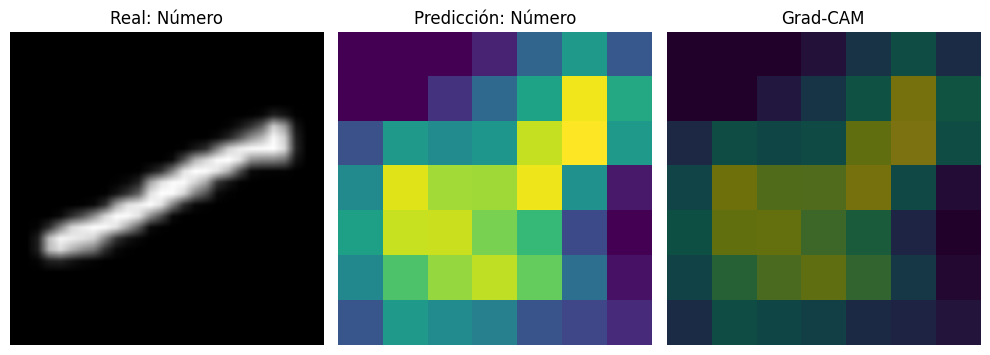

In [ ]:
idx = 0

x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Real: {class_names[int(y)]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Predicción: {class_names[pred_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas

1. **Separación de datos:** mantener conjuntos de entrenamiento, validación y test separados.

2. **Métricas:** no depender únicamente de Accuracy; también observar ROC-AUC, Precision, Recall, F1 y la matriz de confusión.

3. **Data Augmentation:** utilizar transformaciones que no cambien la clase real del carácter.

4. **Reproducibilidad:** fijar una semilla cuando se realicen divisiones aleatorias.

5. **Interpretabilidad:** Grad-CAM ayuda a visualizar qué regiones utiliza el modelo, pero no demuestra por sí solo cómo funciona internamente.

6. **Aplicación:** este ejercicio puede servir como introducción a tareas de reconocimiento de caracteres y clasificación de imágenes.


## 10. Guardar y cargar modelos

Guardaremos los tres modelos entrenados para poder reutilizarlos posteriormente.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch_emnist_binary.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_aug_emnist_binary.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet_transfer_emnist_binary.pth"
)

[
    "models/cnn_scratch_emnist_binary.pth",
    "models/cnn_aug_emnist_binary.pth",
    "models/resnet_transfer_emnist_binary.pth"
]


['models/cnn_scratch_emnist_binary.pth',
 'models/cnn_aug_emnist_binary.pth',
 'models/resnet_transfer_emnist_binary.pth']

## 11. Resumen de la actividad final

Para esta actividad se reemplazó el dataset médico original por **EMNIST ByClass**.

El objetivo fue construir un clasificador binario capaz de determinar si una imagen contiene una **letra** o un **número**.

El pipeline utilizado es:

**EMNIST → adaptación de etiquetas → CNN → Data Augmentation → Transfer Learning → evaluación → Grad-CAM**

### Posibles experimentos

1. Cambiar la arquitectura de la CNN.
2. Modificar el learning rate o el número de épocas.
3. Probar diferentes niveles de Data Augmentation.
4. Comparar la CNN desde cero con ResNet18.
5. Analizar los errores mediante la matriz de confusión.
6. Utilizar Grad-CAM para observar qué regiones del carácter influyen en la predicción.
